
# CHURNGUARD AI
## Customer Churn Prediction & Retention Intelligence System

**Domain:** Artificial Intelligence & Machine Learning  
**Language:** Python  
**Environment:** Google Colab / Jupyter Notebook  
**Dataset:** IBM Telco Customer Churn public sample dataset

### Project workflow
**Raw Data → Data Understanding → Cleaning → Feature Preparation → Model Training → Evaluation → Prediction → Business Insight**

This notebook follows the MainCrafts Technology project brief step-by-step. The project is a **binary supervised classification** problem in which the target is `Churn` (`Yes`/`No`).

> **Important:** Model metrics are generated by running the notebook on the dataset. Do not type or invent metrics manually.



## 1. Project Understanding

### Q1. What is customer churn?
Customer churn means a customer stops using or paying for a company's service. In this project, `Churn = Yes` means the customer left the telecom company.

### Q2. Why predict churn?
1. Identify customers who may need retention attention.
2. Help prioritize retention campaigns instead of treating every customer identically.
3. Understand customer/service patterns associated with churn.
4. Support data-driven decisions about contracts, service support and offers.

### Q3. What is the target variable?
The target variable is **`Churn`**.

### Q4. Classification or regression?
This is a **binary classification** problem because the target has two classes: `Yes` and `No`.

### Q5. What is a false negative?
A false negative occurs when the model predicts **"customer will stay"** but the customer actually **churns**. In a retention setting, this can mean missing a customer who might have benefited from timely retention attention.


## 2. Import Libraries

In [3]:

import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    RocCurveDisplay
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
os.makedirs("evidence", exist_ok=True)

print("Libraries imported successfully.")


Libraries imported successfully.



## 3. Load and Inspect the Dataset

The project brief recommends the IBM Telco Customer Churn dataset. The notebook downloads the public CSV directly, so it can run in Google Colab without requiring a Kaggle account.

If you already have the CSV, set `LOCAL_DATA_PATH` to its path.


In [4]:

DATA_URL = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
LOCAL_DATA_PATH = ""  # Example: "/content/Telco-Customer-Churn.csv"

if LOCAL_DATA_PATH and os.path.exists(LOCAL_DATA_PATH):
    df = pd.read_csv(LOCAL_DATA_PATH)
else:
    df = pd.read_csv(DATA_URL)

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:

print("Dataset information:")
df.info()

print("\nMissing values:")
display(df.isnull().sum().sort_values(ascending=False).to_frame("missing_values").head(15))

print("\nDuplicate rows:", df.duplicated().sum())
print("Duplicate customer IDs:", df["customerID"].duplicated().sum())

print("\nTarget distribution:")
display(df["Churn"].value_counts())
display((df["Churn"].value_counts(normalize=True) * 100).round(2).rename("percentage"))


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  704

,missing_values
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0



Duplicate rows: 0
Duplicate customer IDs: 0

Target distribution:


,count
Churn,
No,5174
Yes,1869


,percentage
Churn,
No,73.46
Yes,26.54



### Initial observations

The dataset contains customer demographic, service, contract and billing information. `customerID` is an identifier rather than a predictive business feature, so it will be removed before modelling.

`TotalCharges` is stored as text in the raw dataset and must be converted to numeric. Blank values become missing values during conversion and are handled explicitly rather than silently ignored.


## 4. Data Cleaning

In [6]:

df_clean = df.copy()

# Convert TotalCharges to numeric; invalid/blank strings become NaN.
df_clean["TotalCharges"] = pd.to_numeric(df_clean["TotalCharges"], errors="coerce")

# Remove exact duplicate records.
before_duplicates = len(df_clean)
df_clean = df_clean.drop_duplicates()
duplicates_removed = before_duplicates - len(df_clean)

# Check missing values created by numeric conversion.
print("Rows before duplicate removal:", before_duplicates)
print("Duplicate rows removed:", duplicates_removed)
print("Missing TotalCharges after conversion:", df_clean["TotalCharges"].isna().sum())

# Show missing-value summary before modelling.
display(df_clean.isnull().sum().sort_values(ascending=False).head(10))


Rows before duplicate removal: 7043
Duplicate rows removed: 0
Missing TotalCharges after conversion: 11


,0
TotalCharges,11
gender,0
SeniorCitizen,0
Partner,0
customerID,0
Dependents,0
tenure,0
MultipleLines,0
PhoneService,0
OnlineSecurity,0



### Why these cleaning steps?

- **Numeric conversion:** machine-learning algorithms need `TotalCharges` as a numeric variable.
- **Duplicate removal:** repeated records can distort model training.
- **Missing-value handling:** missing values are handled inside the preprocessing pipeline using a median strategy for numeric data and the most frequent category for categorical data.
- **Identifier removal:** `customerID` identifies a customer but does not represent a meaningful generalizable churn feature.


## 5. Exploratory Data Analysis (EDA)

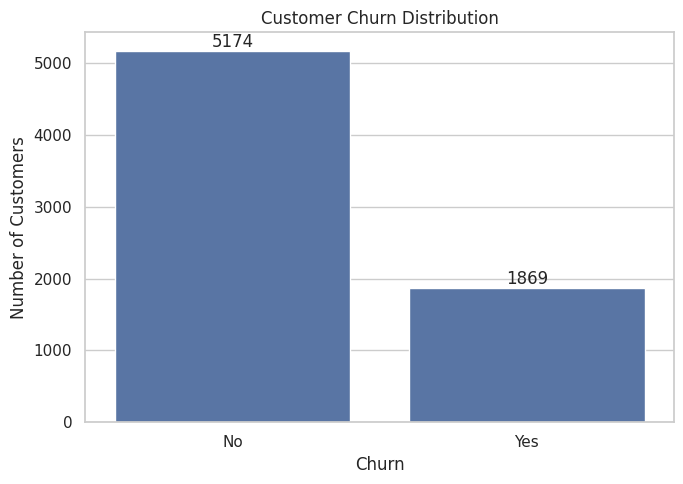

In [7]:

# Visualization 1: Overall churn distribution
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df_clean, x="Churn")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.savefig("evidence/01_churn_distribution.png", dpi=160)
plt.show()


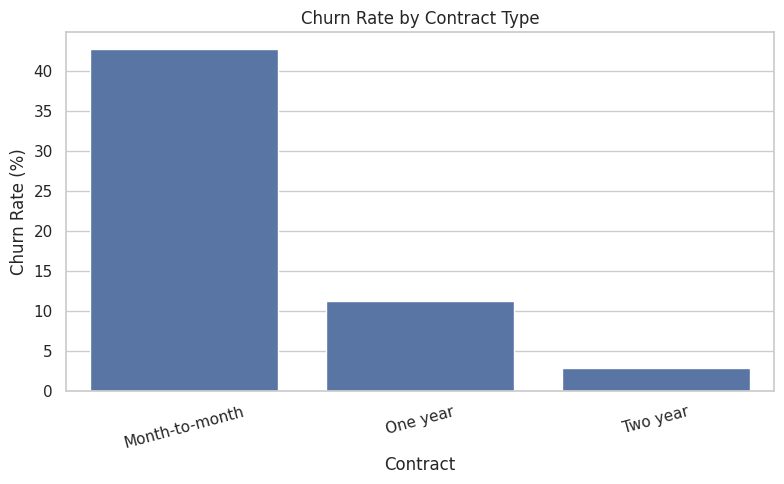

,churn_rate_percent
Contract,
Month-to-month,42.71
One year,11.27
Two year,2.83


In [8]:

# Visualization 2: Churn by contract
contract_rate = (
    df_clean.groupby("Contract")["Churn"]
    .apply(lambda s: (s == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
sns.barplot(x=contract_rate.index, y=contract_rate.values)
plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("evidence/02_churn_by_contract.png", dpi=160)
plt.show()

display(contract_rate.round(2).rename("churn_rate_percent").to_frame())


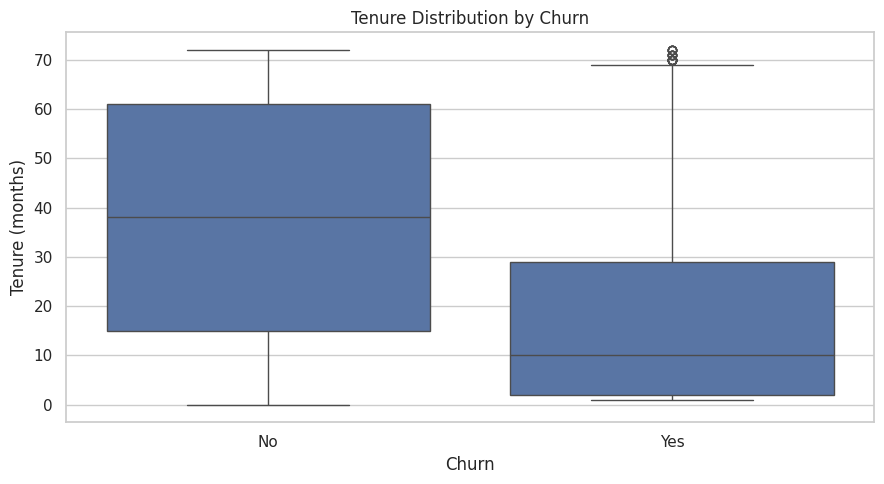

In [9]:

# Visualization 3: Churn by tenure
plt.figure(figsize=(9, 5))
sns.boxplot(data=df_clean, x="Churn", y="tenure")
plt.title("Tenure Distribution by Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (months)")
plt.tight_layout()
plt.savefig("evidence/03_churn_by_tenure.png", dpi=160)
plt.show()


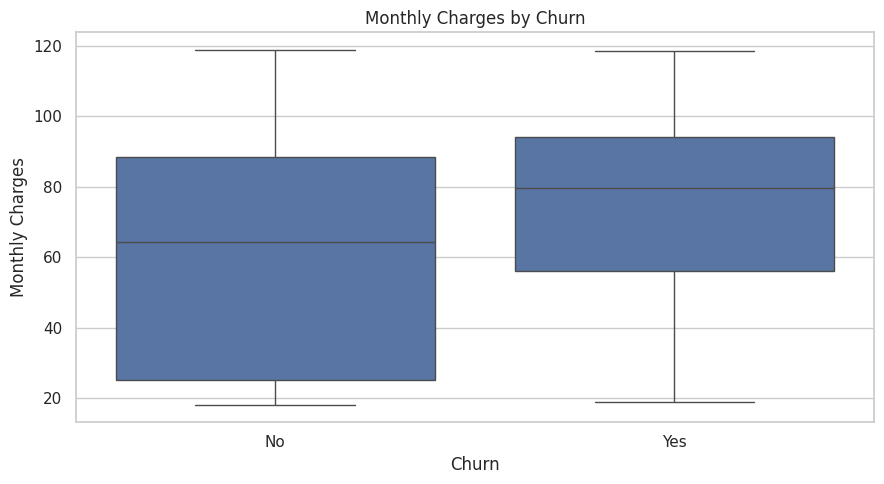

In [10]:

# Visualization 4: Monthly charges by churn
plt.figure(figsize=(9, 5))
sns.boxplot(data=df_clean, x="Churn", y="MonthlyCharges")
plt.title("Monthly Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.tight_layout()
plt.savefig("evidence/04_churn_by_monthly_charges.png", dpi=160)
plt.show()



### EDA interpretation

Use the actual charts above to describe the patterns in your run. Do not copy conclusions from another project.

A professional interpretation should distinguish **association from causation**. For example, if one contract group shows a higher churn rate, write that the group is *associated with higher observed churn in this dataset*, not that the contract type definitely causes churn.


## 6. Prepare Features and Target

In [11]:

model_df = df_clean.copy()

# Target encoding: Yes = 1, No = 0
y = model_df["Churn"].map({"No": 0, "Yes": 1})

# Remove target and customer identifier.
X = model_df.drop(columns=["Churn", "customerID"])

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

print("\nTarget distribution:")
display(y.value_counts().rename(index={0: "No Churn", 1: "Churn"}))


Numeric features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Target distribution:


,count
Churn,
No Churn,5174
Churn,1869


## 7. Train/Test Split

In [12]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Training churn rate:", round(y_train.mean() * 100, 2), "%")
print("Testing churn rate:", round(y_test.mean() * 100, 2), "%")


Training samples: 5634
Testing samples: 1409
Training churn rate: 26.54 %
Testing churn rate: 26.54 %



## 8. Build the Preprocessing Pipeline

Categorical values such as `Contract` and `PaymentMethod` cannot be passed directly to most scikit-learn estimators. One-hot encoding converts them into machine-readable binary columns.

Preprocessing is placed inside a `Pipeline` so that transformations are learned only from the training data. This helps prevent data leakage.


In [13]:

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created.")


Preprocessing pipeline created.


## 9. Train Model #1 — Logistic Regression

In [14]:

logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
])

logistic_model.fit(X_train, y_train)
logistic_pred = logistic_model.predict(X_test)
logistic_prob = logistic_model.predict_proba(X_test)[:, 1]

def evaluate_model(name, y_true, y_pred, y_prob):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_prob)
    }

logistic_results = evaluate_model(
    "Logistic Regression", y_test, logistic_pred, logistic_prob
)

print(classification_report(y_test, logistic_pred, target_names=["No Churn", "Churn"]))


              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



## 10. Train Model #2 — Random Forest

In [15]:

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=400,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

rf_results = evaluate_model(
    "Random Forest", y_test, rf_pred, rf_prob
)

print(classification_report(y_test, rf_pred, target_names=["No Churn", "Churn"]))


              precision    recall  f1-score   support

    No Churn       0.82      0.89      0.85      1035
       Churn       0.60      0.47      0.53       374

    accuracy                           0.78      1409
   macro avg       0.71      0.68      0.69      1409
weighted avg       0.77      0.78      0.77      1409



## 11. Compare Models

In [16]:

results = pd.DataFrame([logistic_results, rf_results])
results_display = results.copy()

for col in ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]:
    results_display[col] = results_display[col].round(4)

display(results_display)

# Primary selection criterion: F1, because churn is the minority class.
# Tie-breakers: Recall, then ROC-AUC.
selected_name = (
    results.sort_values(
        by=["F1", "Recall", "ROC-AUC"],
        ascending=False
    ).iloc[0]["Model"]
)

selected_model = logistic_model if selected_name == "Logistic Regression" else rf_model
selected_pred = logistic_pred if selected_name == "Logistic Regression" else rf_pred
selected_prob = logistic_prob if selected_name == "Logistic Regression" else rf_prob

print("Selected model for the initial comparison:", selected_name)
print("Selection criterion: F1-score, followed by Recall and ROC-AUC.")


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.8055,0.6572,0.5588,0.6040,0.8419
1,Random Forest,0.7779,0.6048,0.4706,0.5293,0.8187


Selected model for the initial comparison: Logistic Regression
Selection criterion: F1-score, followed by Recall and ROC-AUC.



### Why not select using accuracy alone?

Churn is typically the smaller class in this dataset. A model can obtain respectable accuracy while still missing many churners. F1 balances precision and recall, while recall directly reflects how many actual churners were identified.


## 12. Confusion Matrix and ROC Curve

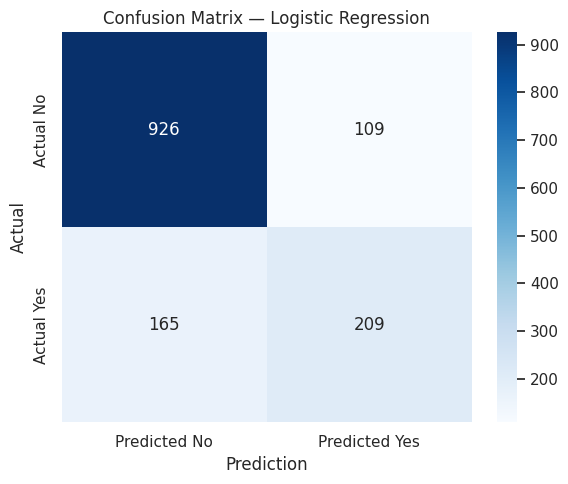

Confusion matrix values [TN, FP; FN, TP]:
[[926 109]
 [165 209]]


In [17]:

cm = confusion_matrix(y_test, selected_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Predicted No", "Predicted Yes"],
    yticklabels=["Actual No", "Actual Yes"]
)
plt.title(f"Confusion Matrix — {selected_name}")
plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("evidence/05_confusion_matrix.png", dpi=160)
plt.show()

print("Confusion matrix values [TN, FP; FN, TP]:")
print(cm)


<Figure size 700x500 with 0 Axes>

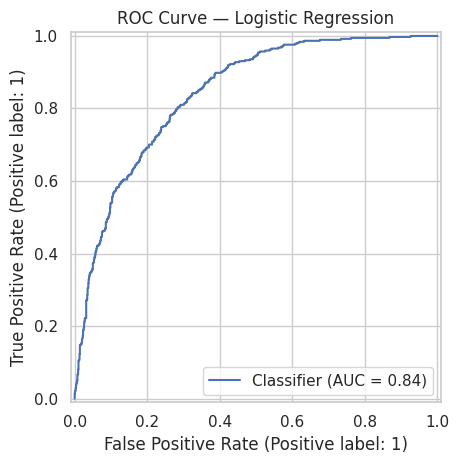

In [18]:

plt.figure(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_test, selected_prob)
plt.title(f"ROC Curve — {selected_name}")
plt.tight_layout()
plt.savefig("evidence/06_roc_curve.png", dpi=160)
plt.show()


## 13. Feature Importance

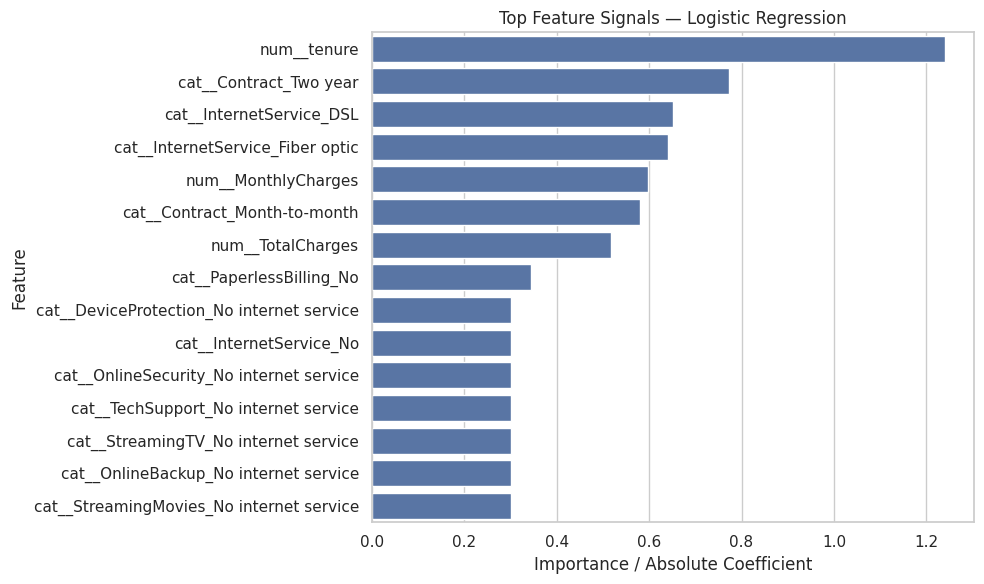

,Feature,Importance,Coefficient
1,num__tenure,1.241319,-1.241319
38,cat__Contract_Two year,0.772261,-0.772261
15,cat__InternetService_DSL,0.652406,-0.652406
16,cat__InternetService_Fiber optic,0.640026,0.640026
2,num__MonthlyCharges,0.596392,-0.596392
36,cat__Contract_Month-to-month,0.579304,0.579304
3,num__TotalCharges,0.516708,0.516708
39,cat__PaperlessBilling_No,0.343260,-0.343260
25,cat__DeviceProtection_No internet service,0.301082,-0.301082
17,cat__InternetService_No,0.301082,-0.301082


In [19]:

def get_feature_names(fitted_pipeline):
    prep = fitted_pipeline.named_steps["preprocessor"]
    return prep.get_feature_names_out()

feature_names = get_feature_names(selected_model)

if selected_name == "Random Forest":
    importances = selected_model.named_steps["classifier"].feature_importances_
    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    })
else:
    coefficients = selected_model.named_steps["classifier"].coef_[0]
    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": np.abs(coefficients),
        "Coefficient": coefficients
    })

importance_df = importance_df.sort_values("Importance", ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x="Importance", y="Feature")
plt.title(f"Top Feature Signals — {selected_name}")
plt.xlabel("Importance / Absolute Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("evidence/07_feature_importance.png", dpi=160)
plt.show()

display(importance_df)



## 14. Customer Prediction Function

The function below converts model probability into a simple risk category:

- **HIGH:** probability ≥ 0.70
- **MEDIUM:** 0.40–0.69
- **LOW:** < 0.40

These thresholds are demonstration bands for the certification project. In a real business deployment, thresholds should be calibrated using validation data and the cost of false positives versus false negatives.


In [20]:

def risk_category(probability):
    if probability >= 0.70:
        return "HIGH"
    elif probability >= 0.40:
        return "MEDIUM"
    return "LOW"

def predict_customer(customer_data, model=selected_model):
    customer_df = pd.DataFrame([customer_data])
    probability = float(model.predict_proba(customer_df)[0, 1])
    prediction = int(probability >= 0.50)

    return {
        "prediction": "Customer likely to churn" if prediction == 1 else "Customer likely to stay",
        "churn_probability": round(probability * 100, 2),
        "risk_level": risk_category(probability)
    }

# Example profile. Change values if you want to test another customer.
sample_customer = {
    "gender": "Female",
    "SeniorCitizen": 0,
    "Partner": "No",
    "Dependents": "No",
    "tenure": 2,
    "PhoneService": "Yes",
    "MultipleLines": "No",
    "InternetService": "Fiber optic",
    "OnlineSecurity": "No",
    "OnlineBackup": "No",
    "DeviceProtection": "No",
    "TechSupport": "No",
    "StreamingTV": "Yes",
    "StreamingMovies": "Yes",
    "Contract": "Month-to-month",
    "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check",
    "MonthlyCharges": 90.0,
    "TotalCharges": 180.0
}

prediction_result = predict_customer(sample_customer)
prediction_result


{'prediction': 'Customer likely to churn',
 'churn_probability': 78.13,
 'risk_level': 'HIGH'}

## 15. Day 2 Improvement — Handle Class Imbalance

In [21]:

# Baseline logistic regression is already available as logistic_model.
baseline_logistic_f1 = f1_score(y_test, logistic_pred, zero_division=0)

# Meaningful improvement: give more weight to the minority churn class.
balanced_logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

balanced_logistic_model.fit(X_train, y_train)
balanced_pred = balanced_logistic_model.predict(X_test)
balanced_prob = balanced_logistic_model.predict_proba(X_test)[:, 1]

balanced_results = evaluate_model(
    "Logistic Regression (Balanced)",
    y_test, balanced_pred, balanced_prob
)

improvement_table = pd.DataFrame([
    {
        "Version": "Before — Logistic Regression",
        "F1": baseline_logistic_f1,
        "Recall": recall_score(y_test, logistic_pred, zero_division=0),
        "Precision": precision_score(y_test, logistic_pred, zero_division=0)
    },
    {
        "Version": "After — Class-Weighted Logistic Regression",
        "F1": balanced_results["F1"],
        "Recall": balanced_results["Recall"],
        "Precision": balanced_results["Precision"]
    }
])

display(improvement_table.round(4))

f1_change = balanced_results["F1"] - baseline_logistic_f1
print(f"F1 change: {f1_change:+.4f}")
print("Reason for change: the minority churn class receives higher training weight.")


,Version,F1,Recall,Precision
0,Before — Logistic Regression,0.6040,0.5588,0.6572
1,After — Class-Weighted Logistic Regression,0.6136,0.7834,0.5043


F1 change: +0.0096
Reason for change: the minority churn class receives higher training weight.



### Improvement interpretation

The purpose of `class_weight="balanced"` is to reduce the tendency of a classifier to focus mainly on the majority non-churn class.

Report the **actual before/after values from the table above**. If F1 improves, state that it improved on this test split. If F1 decreases but recall improves, state that trade-off instead. This is better than claiming that an improvement worked before observing the results.


## 16. Final Model Selection

In [22]:

all_results = pd.DataFrame([
    logistic_results,
    rf_results,
    balanced_results
])

display(all_results.round(4))

# Final selection: prioritize F1, then recall, then ROC-AUC.
final_selected_name = (
    all_results.sort_values(
        by=["F1", "Recall", "ROC-AUC"],
        ascending=False
    ).iloc[0]["Model"]
)

model_map = {
    "Logistic Regression": logistic_model,
    "Random Forest": rf_model,
    "Logistic Regression (Balanced)": balanced_logistic_model
}
final_model = model_map[final_selected_name]

if final_selected_name == "Logistic Regression":
    final_pred, final_prob = logistic_pred, logistic_prob
elif final_selected_name == "Random Forest":
    final_pred, final_prob = rf_pred, rf_prob
else:
    final_pred, final_prob = balanced_pred, balanced_prob

final_metrics = all_results[all_results["Model"] == final_selected_name].iloc[0]

print("FINAL SELECTED MODEL:", final_selected_name)
print(final_metrics.round(4))


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.8055,0.6572,0.5588,0.6040,0.8419
1,Random Forest,0.7779,0.6048,0.4706,0.5293,0.8187
2,Logistic Regression (Balanced),0.7381,0.5043,0.7834,0.6136,0.8413


FINAL SELECTED MODEL: Logistic Regression (Balanced)
Model        Logistic Regression (Balanced)
Accuracy                           0.738112
Precision                          0.504303
Recall                             0.783422
F1                                 0.613613
ROC-AUC                            0.841298
Name: 2, dtype: object


## 17. Save the Trained Model

In [23]:

MODEL_PATH = "churn_guard_ai_model.joblib"
joblib.dump(final_model, MODEL_PATH)
print("Saved:", MODEL_PATH)


Saved: churn_guard_ai_model.joblib



## 18. Business Interpretation

### Model Performance
The final selected model's actual Accuracy, Precision, Recall and F1-score are shown in the final results table. Use those values in the project report.

### Business Interpretation
CHURNGUARD AI can help a company identify customers whose observed characteristics are associated with higher churn probability. The output can be used to prioritize retention attention.

### Possible Actions
- Review high-risk customers for service or billing issues.
- Consider targeted retention offers where commercially appropriate.
- Review month-to-month customers and early-tenure customers more closely if the EDA confirms elevated churn in those groups.
- Investigate support/service combinations associated with higher observed churn.

### Limitation
A prediction is not a guarantee that an individual customer will churn. The dataset is a historical sample, and model performance can change when customer behavior, pricing, products or market conditions change.


## 19. CHURNGUARD AI — FINAL RESULTS

In [24]:

print("CHURNGUARD AI — FINAL RESULTS")
print("=" * 55)
print("Dataset records:", len(df_clean))
print("Original columns:", df.shape[1])
print("Models tested:", ", ".join(all_results["Model"].tolist()))
print("Selected model:", final_selected_name)
print(f"Accuracy:  {final_metrics['Accuracy']:.4f}")
print(f"Precision: {final_metrics['Precision']:.4f}")
print(f"Recall:    {final_metrics['Recall']:.4f}")
print(f"F1 Score:  {final_metrics['F1']:.4f}")
print(f"ROC-AUC:   {final_metrics['ROC-AUC']:.4f}")
print("=" * 55)

print("\nTop observed feature signals:")
display(importance_df.head(10))


CHURNGUARD AI — FINAL RESULTS
Dataset records: 7043
Original columns: 21
Models tested: Logistic Regression, Random Forest, Logistic Regression (Balanced)
Selected model: Logistic Regression (Balanced)
Accuracy:  0.7381
Precision: 0.5043
Recall:    0.7834
F1 Score:  0.6136
ROC-AUC:   0.8413

Top observed feature signals:


,Feature,Importance,Coefficient
1,num__tenure,1.241319,-1.241319
38,cat__Contract_Two year,0.772261,-0.772261
15,cat__InternetService_DSL,0.652406,-0.652406
16,cat__InternetService_Fiber optic,0.640026,0.640026
2,num__MonthlyCharges,0.596392,-0.596392
36,cat__Contract_Month-to-month,0.579304,0.579304
3,num__TotalCharges,0.516708,0.516708
39,cat__PaperlessBilling_No,0.343260,-0.343260
25,cat__DeviceProtection_No internet service,0.301082,-0.301082
17,cat__InternetService_No,0.301082,-0.301082



## 20. Submission Checklist

Before submitting:

- [ ] `.ipynb` notebook runs from top to bottom.
- [ ] Dataset preview is visible.
- [ ] At least 4 EDA visualizations are visible.
- [ ] Missing values and duplicates are handled and explained.
- [ ] Logistic Regression is trained.
- [ ] Random Forest is trained.
- [ ] Models are compared using accuracy, precision, recall and F1.
- [ ] Confusion matrix is included.
- [ ] Feature importance/signals are included.
- [ ] Customer prediction function works.
- [ ] Day 2 improvement has before/after F1 comparison.
- [ ] Risk category output is shown.
- [ ] Model is saved with Joblib.
- [ ] Final results section is completed from the actual notebook output.
- [ ] Evidence images are saved in `evidence/`.
- [ ] Project report is exported to PDF.
- [ ] README is uploaded to GitHub.
